# Micro-organism Image Classification — GoogLeNet / Inception V1 (Built From Scratch)

**Goal:** Same task and same dataset as the AlexNet/VGG-from-scratch notebook — classify microscope
images of micro-organisms into their correct type — completing the "built from scratch, no
pretrained weights" trilogy for this project. This time the architecture is **GoogLeNet** (also
called **Inception V1**), introduced by Szegedy et al. in 2014 — the same year as VGG, and the
*other* big idea that came out of that year's ImageNet competition (ILSVRC 2014, which GoogLeNet
won outright).

**Why GoogLeNet, after AlexNet and VGG?** AlexNet and VGG both use a **plain, linear stack** of
layers — one operation after another in a single sequence, with just one filter size chosen at each
layer. GoogLeNet asks a genuinely different question: instead of forcing the network to pick *one*
filter size per layer (3x3? 5x5?), why not compute several filter sizes **in parallel, side by
side**, on the exact same input, and let the network combine all of them together? That single idea
— the **Inception module** — is also why this notebook needs the Keras **Functional API** (`Model`)
instead of `Sequential`: for the first time in this project, the network's data flow is no longer a
straight line, it *branches and rejoins*.

The result, historically, was a network that was simultaneously **deeper** than AlexNet or VGG (22
layers with learnable weights, by the original paper's count) and **far lighter**: the original
GoogLeNet used roughly **12x fewer parameters than AlexNet** and **over 20x fewer than VGG**, while
still winning ILSVRC 2014 with a 6.67% top-5 error rate. We'll see the same pattern hold on our own
8-class dataset once it's built below.

**A note on scale (same caution as before):** GoogLeNet is deeper and structurally more complex than
either AlexNet or VGG, and our micro-organism dataset is tiny compared to the 1.2-million-image
ImageNet dataset it was designed for. Expect the same overfitting risk already seen with AlexNet and
VGG on this dataset — this is, again, exactly the point of building it from scratch: to see the
theory in action, not to chase a leaderboard number.

## Step 1: Import the Libraries

Same core imports as the AlexNet/VGG notebook, with one important difference: GoogLeNet needs the
**Functional API** (`Model`, `Input`), not `Sequential`. `Sequential` only works for a single,
straight-line stack of layers — but the Inception module's four parallel branches, joined back
together with `Concatenate`, simply can't be expressed that way. This is the first architecture in
this project where the network's data flow is a graph, not a line.

- `os` and `pathlib` — for working with folders and file paths.
- `numpy` — for numerical operations.
- `matplotlib.pyplot` — for plotting images and graphs.
- `tensorflow` / `keras` — the deep learning library, plus `Concatenate` (to merge the four
  Inception branches back together) and `Activation` (kept as its own layer here, since every
  convolution below is followed by `BatchNormalization` *before* its ReLU — see the `conv_block`
  helper in Step 6).

In [1]:
# Basic Python tools for handling files and folders
import os
from pathlib import Path

# Numerical operations
import numpy as np

# For plotting images and graphs
import matplotlib.pyplot as plt

# Deep learning library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout,
    BatchNormalization, Activation, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Just to check everything installed correctly and see which TensorFlow version we have
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 2: Set the Dataset Path and Basic Parameters

Same micro-organism dataset as the AlexNet/VGG notebook. A couple of settings are chosen
specifically with GoogLeNet in mind:

- `IMG_HEIGHT`, `IMG_WIDTH` — **224x224**, the same input size used throughout this project, so all
  three from-scratch models stay directly comparable.
- `BATCH_SIZE` — kept at 32. GoogLeNet actually has *far fewer* parameters than VGG (see Step 6),
  but its many parallel branches mean more intermediate feature maps are held in memory at once
  during training, so we don't increase the batch size just because the parameter count is lighter.
- `EPOCHS` — same generous budget as AlexNet/VGG; `EarlyStopping` (Step 8) will stop things
  automatically once validation performance plateaus.

**Important:** Update `DATASET_DIR` below if your folder path is different.

In [2]:
# Path to the main dataset folder (one sub-folder per micro-organism type).
from google.colab import drive
drive.mount('/content/drive')

# Then update your dataset path to point to Drive
DATASET_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Micro_Organism")

# Same 224x224 input size used for AlexNet and VGG earlier in this project
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# How many images are shown to the model at once during training
BATCH_SIZE = 32

# Trained from scratch, so give it plenty of epochs to work with —
# EarlyStopping (Step 8) will cut training short once validation loss stops improving
EPOCHS = 40

# Fraction of the data set aside for validation
VALIDATION_SPLIT = 0.2

# Fixed seed so the train/validation split is reproducible with the other notebooks
SEED = 42

Mounted at /content/drive


## Step 3: Explore the Dataset

Same exploration as the other micro-organism notebooks — check the micro-organism type names and
how many images each one has, since class imbalance affects a from-scratch model even more than a
fine-tuned one.

In [3]:
class_names = sorted([folder.name for folder in DATASET_DIR.iterdir() if folder.is_dir()])

print("Number of micro-organism types (classes) found:", len(class_names))
for name in class_names:
    print(" -", name)

Number of micro-organism types (classes) found: 8
 - Amoeba
 - Euglena
 - Hydra
 - Paramecium
 - Rod_bacteria
 - Spherical_bacteria
 - Spiral_bacteria
 - Yeast


Number of images per micro-organism type:
 - Amoeba: 72 images
 - Euglena: 168 images
 - Hydra: 76 images
 - Paramecium: 152 images
 - Rod_bacteria: 85 images
 - Spherical_bacteria: 86 images
 - Spiral_bacteria: 75 images
 - Yeast: 75 images

Total images: 789


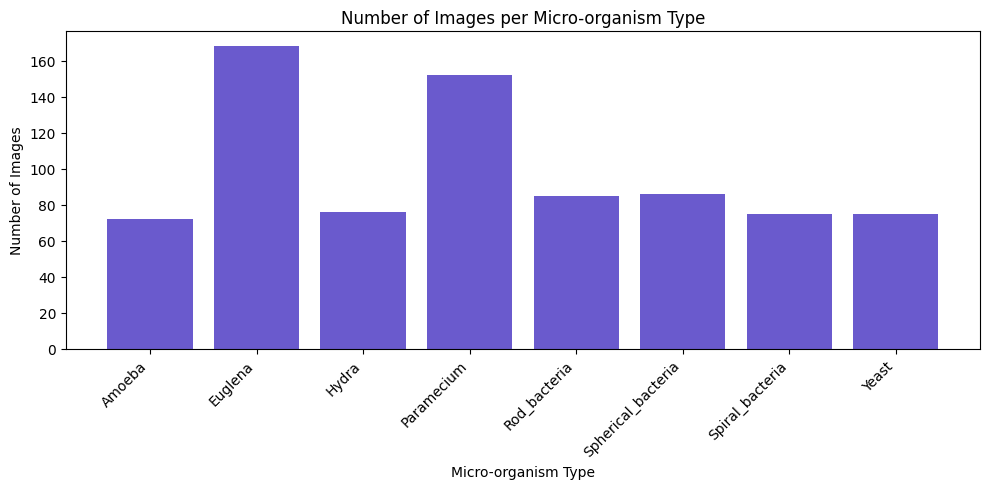

In [4]:
image_counts = {}

for class_name in class_names:
    class_folder = DATASET_DIR / class_name
    num_images = len([f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]])
    image_counts[class_name] = num_images

print("Number of images per micro-organism type:")
for class_name, count in image_counts.items():
    print(f" - {class_name}: {count} images")

print("\nTotal images:", sum(image_counts.values()))

plt.figure(figsize=(10, 5))
plt.bar(image_counts.keys(), image_counts.values(), color="slateblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Micro-organism Type")
plt.ylabel("Number of Images")
plt.title("Number of Images per Micro-organism Type")
plt.tight_layout()
plt.show()

## Step 4: Visualize Sample Images

A quick visual check that the images loaded correctly, and a reminder of what each micro-organism
type actually looks like under the microscope before we start building GoogLeNet.

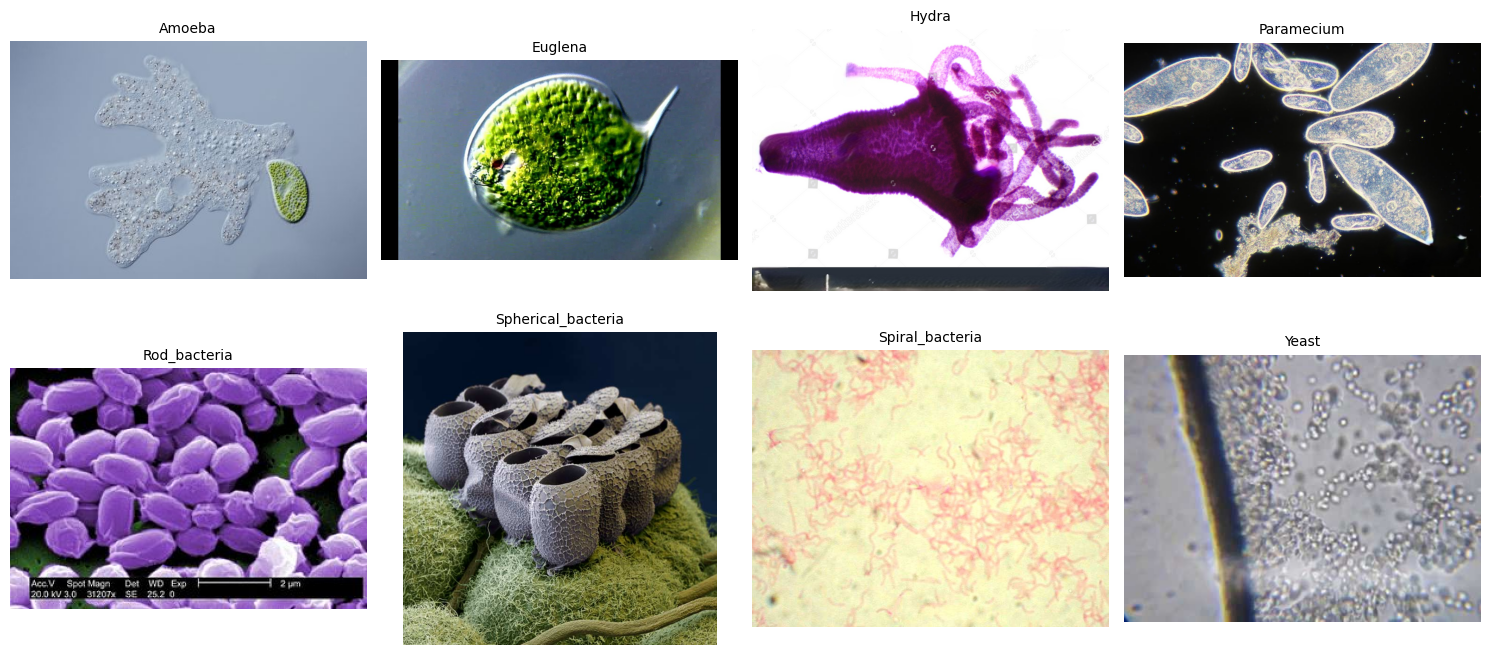

In [5]:
plt.figure(figsize=(15, 10))

for i, class_name in enumerate(class_names):
    class_folder = DATASET_DIR / class_name

    image_files = [f for f in class_folder.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    if len(image_files) == 0:
        continue
    sample_image_path = image_files[0]

    img = keras.preprocessing.image.load_img(sample_image_path)
    plt.subplot(3, 4, i + 1)  # Adjust grid size (rows, cols) if you have more/fewer classes
    plt.imshow(img)
    plt.title(class_name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 5: Prepare the Data for Training

Since GoogLeNet is built from scratch (no pretrained base model), there's no architecture-specific
`preprocess_input` to worry about — just a plain `rescale=1./255` to bring pixel values into the
`[0, 1]` range, exactly like the AlexNet/VGG notebook.

Data augmentation matters for the same reason it did there: a randomly-initialized network has no
prior visual knowledge to fall back on, so it's much more prone to simply memorizing the
(relatively small) training set instead of learning generalizable features.

In [6]:
# ImageDataGenerator for the TRAINING data.
# rescale=1./255 converts pixel values from [0, 255] to [0, 1]
# The other parameters randomly modify the images slightly (data augmentation) to create more variety
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.8, 1.2),
    shear_range=0.1,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

# Validation data: only rescaled, no augmentation — we want to evaluate on realistic, unmodified images
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VALIDATION_SPLIT
)

In [7]:
# Automatically find all images inside DATASET_DIR, resize them, and assign labels
# based on their folder name. subset="training" picks 80% of the data for training.
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

# subset="validation" picks the remaining 20% of the data for validation.
validation_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED
)

num_classes = len(class_names)
print("Class indices used by the model:", train_generator.class_indices)

Found 633 images belonging to 8 classes.
Found 156 images belonging to 8 classes.
Class indices used by the model: {'Amoeba': 0, 'Euglena': 1, 'Hydra': 2, 'Paramecium': 3, 'Rod_bacteria': 4, 'Spherical_bacteria': 5, 'Spiral_bacteria': 6, 'Yeast': 7}


## Step 6: Theory — Inside GoogLeNet's Architecture

GoogLeNet is built from one repeating building block — the **Inception module** — stacked 9 times,
with a small "stem" of ordinary convolutions and poolings before the first one. Here's what makes it
different from AlexNet and VGG's plain stacks:

1. **The Inception module: multiple filter sizes, computed in parallel.** Instead of picking one
   filter size per layer, each Inception module runs **four branches at once** on the *same* input,
   then concatenates all four outputs back together along the channel dimension:
   - a `1x1` convolution (looks at a single pixel's channels — cheap, and good at combining
     channel-wise information)
   - a `1x1` convolution, then a `3x3` convolution (a medium-sized receptive field)
   - a `1x1` convolution, then a `5x5` convolution (a large receptive field)
   - a `3x3` max-pool, then a `1x1` convolution (a pooling path, which the original paper found
     helps too)

   The network doesn't have to "guess" the right filter size for a given layer — it computes several
   at once and, through training, learns how much weight to give each scale.

2. **`1x1` convolutions as a "bottleneck": the trick that makes this affordable.** Running a full
   `5x5` convolution directly on a wide input (192 channels, say) is expensive. So before each
   expensive `3x3` or `5x5` convolution, a cheap `1x1` convolution first *shrinks* the number of
   channels (e.g. 192 -> 16), and only then does the bigger convolution run — on that much narrower
   input. Concretely, for Inception module `3a` in the network below (192 input channels, reduced to
   16 before a `5x5` convolution up to 32 output channels):
   - **Without** the `1x1` bottleneck: a `5x5` conv straight from 192 -> 32 channels needs
     `5 x 5 x 192 x 32 = 153,600` weights.
   - **With** the bottleneck: a `1x1` conv (192 -> 16, `1x1x192x16 = 3,072` weights) followed by a
     `5x5` conv (16 -> 32, `5x5x16x32 = 12,800` weights) needs only `3,072 + 12,800 = 15,872` weights
     — roughly **90% fewer**, for the same job.

   This is the single biggest reason GoogLeNet can be *both* deeper and lighter than AlexNet or VGG.

3. **Global Average Pooling instead of giant Dense layers.** Just like the VGG variant built earlier
   in this project, GoogLeNet collapses its final feature maps with `GlobalAveragePooling2D` rather
   than `Flatten` + huge `Dense` layers — except GoogLeNet's *original* 2014 design always worked
   this way (VGG's authors used a giant `Flatten` + two `Dense(4096)` layers; using GAP for VGG here
   was our project's own space-saving modification). Combined with the `1x1` bottlenecks throughout,
   this is why GoogLeNet ends up so parameter-light despite being the deepest of the three.

4. **Auxiliary classifiers (a historical detail we simplify away).** The full 22-layer-deep original
   network worried that gradients might weaken by the time they backpropagated from the output all
   the way back to the earliest layers. So the paper attached two small extra classifier
   "side-branches" partway through the network — each producing its own softmax prediction and its
   own loss, but *only during training*. Both side-branches are thrown away at inference time; only
   the main classifier at the end is ever actually used to make predictions. Modern training tricks
   (BatchNormalization, better weight initialization) have made this trick largely unnecessary, and
   wiring up multiple weighted-loss outputs adds real complexity to a beginner Keras workflow — so,
   matching this project's own "simplify historical quirks, explain why" pattern (see AlexNet's notes
   on LRN and two-GPU training), we build the simpler single-output version below.

5. **Why "Inception"?** GoogLeNet's name is an homage to LeNet (one of the very first CNNs), and the
   module's internal codename, "Inception," is widely reported to be a nod to the "we need to go
   deeper" internet meme from the movie *Inception* — a fittingly self-aware joke for an architecture
   whose entire goal was to go deeper without the usual parameter explosion.

**Shape, from a 224x224x3 input — verified by actually building and running this exact model:**

| Stage | What happens | Output shape |
|---|---|---|
| Input | — | 224x224x3 |
| Stem | Conv 7x7, stride 2 | 112x112x64 |
| Stem | MaxPool 3x3, stride 2 | 56x56x64 |
| Stem | Conv 1x1, then Conv 3x3 | 56x56x192 |
| Stem | MaxPool 3x3, stride 2 | 28x28x192 |
| Inception 3a | 4 parallel branches, concatenated | 28x28x256 |
| Inception 3b | 4 parallel branches, concatenated | 28x28x480 |
| — | MaxPool 3x3, stride 2 | 14x14x480 |
| Inception 4a | 4 parallel branches, concatenated | 14x14x512 |
| Inception 4b | 4 parallel branches, concatenated | 14x14x512 |
| Inception 4c | 4 parallel branches, concatenated | 14x14x512 |
| Inception 4d | 4 parallel branches, concatenated | 14x14x528 |
| Inception 4e | 4 parallel branches, concatenated | 14x14x832 |
| — | MaxPool 3x3, stride 2 | 7x7x832 |
| Inception 5a | 4 parallel branches, concatenated | 7x7x832 |
| Inception 5b | 4 parallel branches, concatenated | 7x7x1024 |
| Head | GlobalAveragePooling2D, then Dropout(0.4) | 1024 |
| Output | Dense + Softmax | `num_classes` |

**Historically:** the original GoogLeNet (~5-7 million parameters, 1000 ImageNet classes) used
roughly **12x fewer parameters than the original AlexNet** (~60 million) and **over 20x fewer than
the original VGG** (~138 million) — while achieving *better* accuracy than both, and winning ILSVRC
2014. Once we build it below for our own 8-class dataset, the summary will show the same pattern
holds here too: it easily ends up the lightest of the three architectures built from scratch in this
project, despite also being the deepest.

In [8]:
def conv_block(x, filters, kernel_size, strides=1, padding="same"):
    """A small, reusable helper: Conv2D -> BatchNorm -> ReLU, bundled together.

    GoogLeNet uses this exact combination dozens of times (almost every single convolution in
    every Inception module below), so writing it once here keeps the rest of the code readable
    instead of repeating the same three lines constantly.

    use_bias=False because BatchNormalization's own shift parameter makes a separate bias term
    redundant -- one less thing to learn, with no loss in what the layer can express.
    """
    x = Conv2D(filters, kernel_size, strides=strides, padding=padding, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    return x


def inception_module(x, f1x1, f3x3_reduce, f3x3, f5x5_reduce, f5x5, pool_proj):
    """One Inception module: four parallel branches looking at the same input `x` at the same
    time, then concatenated together along the channel axis (see Step 6, idea #1).

    Argument names match the original paper's own naming:
    - f1x1        : filters for the plain 1x1 branch
    - f3x3_reduce : filters for the 1x1 bottleneck BEFORE the 3x3 branch
    - f3x3        : filters for the 3x3 branch (after the bottleneck)
    - f5x5_reduce : filters for the 1x1 bottleneck BEFORE the 5x5 branch
    - f5x5        : filters for the 5x5 branch (after the bottleneck)
    - pool_proj   : filters for the 1x1 projection AFTER the pooling branch
    """
    # Branch 1: a single 1x1 conv
    branch1 = conv_block(x, f1x1, (1, 1))

    # Branch 2: 1x1 bottleneck, then 3x3 conv
    branch2 = conv_block(x, f3x3_reduce, (1, 1))
    branch2 = conv_block(branch2, f3x3, (3, 3))

    # Branch 3: 1x1 bottleneck, then 5x5 conv
    branch3 = conv_block(x, f5x5_reduce, (1, 1))
    branch3 = conv_block(branch3, f5x5, (5, 5))

    # Branch 4: 3x3 max-pool, then a 1x1 projection back down to a reasonable channel count
    branch4 = MaxPooling2D((3, 3), strides=1, padding="same")(x)
    branch4 = conv_block(branch4, pool_proj, (1, 1))

    # Concatenate all four branches along the channel axis -- the "combine everything the
    # network computed at every scale" step that gives Inception modules their name.
    return Concatenate(axis=-1)([branch1, branch2, branch3, branch4])


def build_googlenet(input_shape, num_classes):
    """Builds GoogLeNet / Inception V1, adapted from the Szegedy et al. 2014 paper.

    Simplifications from the original paper (explained in Step 6):
    - No auxiliary classifiers (a historical training aid, not needed at inference time).
    - BatchNormalization after every convolution (the original paper predates BatchNorm --
      this matches the same modernization already applied to AlexNet earlier in this project).
    """
    inputs = Input(shape=input_shape)

    # --- Stem: a few ordinary conv/pool layers to shrink the huge input before the
    # (much more expensive) Inception modules begin ---
    x = conv_block(inputs, 64, (7, 7), strides=2)
    x = MaxPooling2D((3, 3), strides=2, padding="same")(x)
    x = conv_block(x, 64, (1, 1))
    x = conv_block(x, 192, (3, 3))
    x = MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # --- Inception block 3: two modules, then pool ---
    x = inception_module(x, 64, 96, 128, 16, 32, 32)      # 3a
    x = inception_module(x, 128, 128, 192, 32, 96, 64)    # 3b
    x = MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # --- Inception block 4: five modules, then pool ---
    x = inception_module(x, 192, 96, 208, 16, 48, 64)     # 4a
    x = inception_module(x, 160, 112, 224, 24, 64, 64)    # 4b
    x = inception_module(x, 128, 128, 256, 24, 64, 64)    # 4c
    x = inception_module(x, 112, 144, 288, 32, 64, 64)    # 4d
    x = inception_module(x, 256, 160, 320, 32, 128, 128)  # 4e
    x = MaxPooling2D((3, 3), strides=2, padding="same")(x)

    # --- Inception block 5: two modules ---
    x = inception_module(x, 256, 160, 320, 32, 128, 128)  # 5a
    x = inception_module(x, 384, 192, 384, 48, 128, 128)  # 5b

    # --- Classifier head: Global Average Pooling, exactly like the original paper ---
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="GoogLeNet")
    return model


googlenet_model = build_googlenet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=num_classes)

## Step 7: Compile GoogLeNet

Same optimizer settings as AlexNet and VGG, so the three-way comparison later isn't muddied by
different training hyperparameters.

Check the summary's total parameter count against AlexNet's and VGG's once it prints below —
despite being the *deepest* of the three (22 layers with weights, against AlexNet's 8 and VGG's 16),
it should also be by far the *lightest*, thanks to the 1x1 bottlenecks and Global Average Pooling
covered in Step 6.

In [9]:
googlenet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

googlenet_model.summary()

Model: "GoogLeNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      4,096 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │    110,592 │ activation_1[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        768 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 28, 28,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 28, 28,    │     18,432 │ max_pooling2d_1[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │      3,072 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        384 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         64 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 6,003,592 (22.90 MB)

 Trainable params: 5,989,032 (22.85 MB)

 Non-trainable params: 14,560 (56.88 KB)

## Step 8: Set Up Training Callbacks for GoogLeNet

Same two core callbacks used throughout this project, plus `ReduceLROnPlateau` (as with VGG):

- **EarlyStopping** — stops training once validation loss stops improving for a few epochs in a
  row, and restores the best weights found.
- **ModelCheckpoint** — saves the best version of the model (by validation accuracy) as training
  progresses, so we always keep the best checkpoint even if later epochs get worse.
- **ReduceLROnPlateau** — GoogLeNet is the deepest network built in this project so far (22 layers
  with weights, spread across 9 Inception modules); gently halving the learning rate when
  validation loss plateaus, instead of only stopping outright, gives a network this deep a better
  chance to settle into a good minimum before `EarlyStopping` eventually kicks in.

In [10]:
early_stop_googlenet = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

checkpoint_googlenet = ModelCheckpoint(
    "best_microorganism_googlenet.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# Halve the learning rate if validation loss plateaus for 3 epochs in a row
reduce_lr_googlenet = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

## Step 9: Train GoogLeNet

Even though GoogLeNet has far fewer parameters than VGG, its many parallel branches mean each epoch
still involves a lot of separate convolution operations, so don't expect it to be dramatically
faster per epoch than VGG was. As with the earlier models, `EarlyStopping` will cut training short
automatically once validation loss stops improving.

In [11]:
history_googlenet = googlenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[early_stop_googlenet, checkpoint_googlenet, reduce_lr_googlenet]
)

Epoch 1/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 430s 18s/step - accuracy: 0.2133 - loss: 2.1168 - val_accuracy: 0.2115 - val_loss: 2.0683 - learning_rate: 1.0000e-04
Epoch 2/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 841ms/step - accuracy: 0.3112 - loss: 1.9249 - val_accuracy: 0.2115 - val_loss: 2.0767 - learning_rate: 1.0000e-04
Epoch 3/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 785ms/step - accuracy: 0.3460 - loss: 1.7401 - val_accuracy: 0.0897 - val_loss: 2.1178 - learning_rate: 1.0000e-04
Epoch 4/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 794ms/step - accuracy: 0.3665 - loss: 1.6546 - val_accuracy: 0.0962 - val_loss: 2.1797 - learning_rate: 1.0000e-04
Epoch 5/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 793ms/step - accuracy: 0.4250 - loss: 1.5838 - val_accuracy: 0.0962 - val_loss: 2.2356 - learning_rate: 5.0000e-05
Epoch 6/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 774ms/step - accuracy: 0.4013 - loss: 1.5411 - val_accuracy: 0.0962 - val_loss: 2.3305 - learning_rate: 5.0000e-05
Epoch 7/40
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 767ms/step - accu

## Step 10: Plot GoogLeNet's Training History

Same accuracy/loss curves as before. Watch for the same training-vs-validation gap seen with
AlexNet and VGG — with a network this deep trained on a small dataset, some overfitting is expected,
though GoogLeNet's much lighter classifier head (Step 6, idea #3) may narrow that gap compared to
AlexNet's.

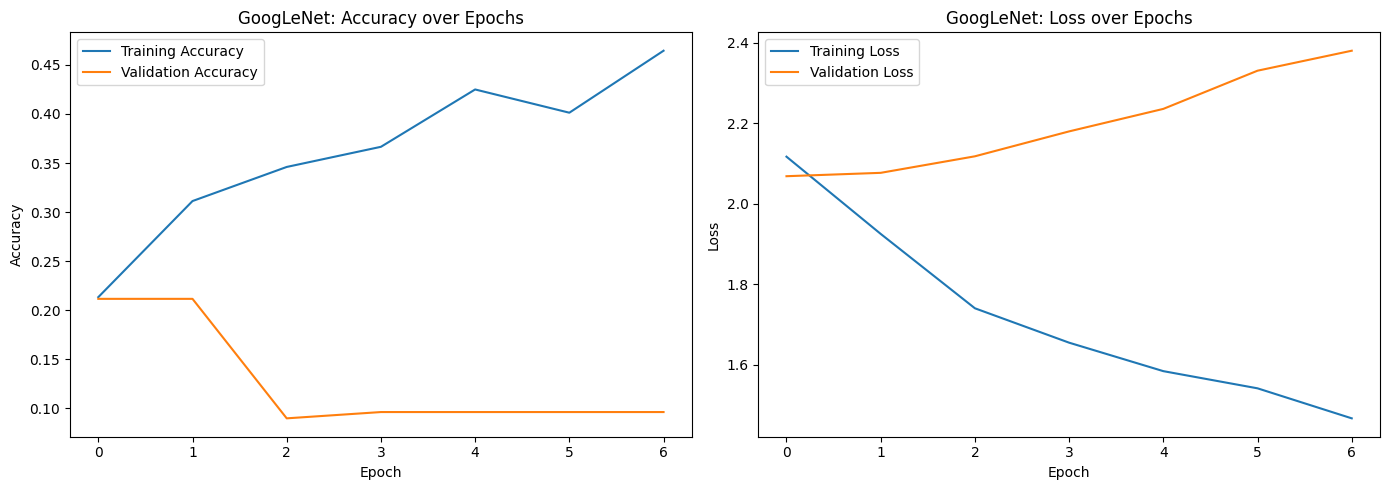

In [12]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_googlenet.history["accuracy"], label="Training Accuracy")
plt.plot(history_googlenet.history["val_accuracy"], label="Validation Accuracy")
plt.title("GoogLeNet: Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_googlenet.history["loss"], label="Training Loss")
plt.plot(history_googlenet.history["val_loss"], label="Validation Loss")
plt.title("GoogLeNet: Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Step 11: Evaluate GoogLeNet

Check GoogLeNet's final validation accuracy and loss. We'll compare this against AlexNet's and
VGG16's results (from the other notebook) in the final comparison section below.

In [13]:
googlenet_val_loss, googlenet_val_accuracy = googlenet_model.evaluate(validation_generator)

print(f"GoogLeNet Validation Loss: {googlenet_val_loss:.4f}")
print(f"GoogLeNet Validation Accuracy: {googlenet_val_accuracy:.4f} ({googlenet_val_accuracy * 100:.2f}%)")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - accuracy: 0.2115 - loss: 2.0683
GoogLeNet Validation Loss: 2.0683
GoogLeNet Validation Accuracy: 0.2115 (21.15%)


## Step 12: Test GoogLeNet on Some Sample Images

Same sanity check as the other notebooks — take one batch of validation images, get GoogLeNet's
predicted micro-organism type for each, and compare against the true labels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


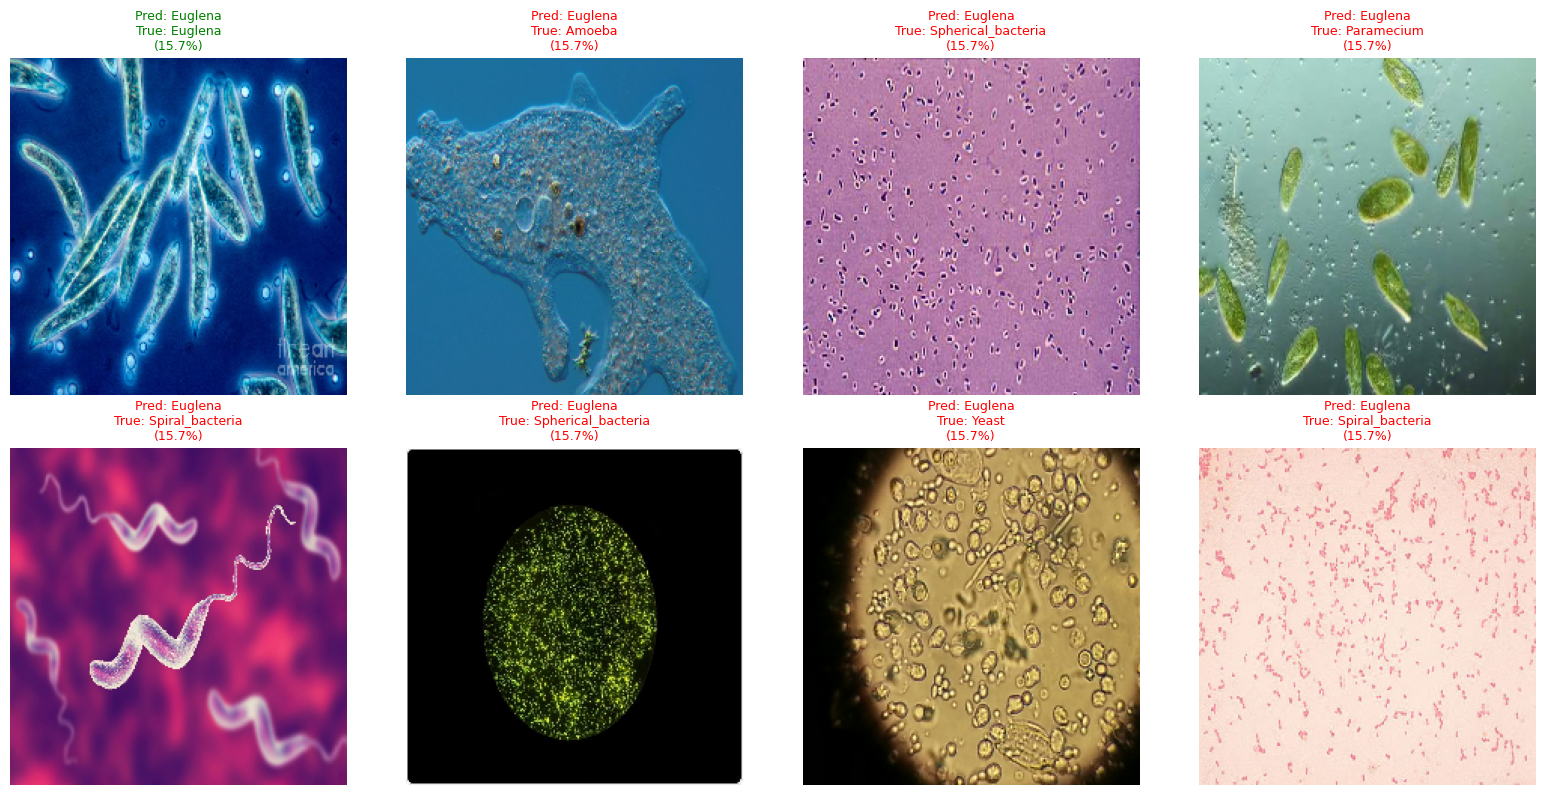

In [14]:
sample_images, sample_labels = next(validation_generator)
predictions = googlenet_model.predict(sample_images)

index_to_class = {v: k for k, v in train_generator.class_indices.items()}

plt.figure(figsize=(16, 8))
num_to_show = min(8, len(sample_images))

for i in range(num_to_show):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i])

    predicted_class = index_to_class[np.argmax(predictions[i])]
    true_class = index_to_class[np.argmax(sample_labels[i])]
    confidence = np.max(predictions[i]) * 100

    color = "green" if predicted_class == true_class else "red"
    plt.title(f"Pred: {predicted_class}\nTrue: {true_class}\n({confidence:.1f}%)",
              color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 13: Save the Final Model

In [15]:
googlenet_model.save("microorganism_googlenet_scratch.keras")
print("Model saved as microorganism_googlenet_scratch.keras")

Model saved as microorganism_googlenet_scratch.keras


## Comparing All Three "Built From Scratch" Models

| | AlexNet (scratch) | VGG16 (scratch) | GoogLeNet (scratch, this notebook) |
|---|---|---|---|
| Year | 2012 | 2014 | 2014 |
| Weight layers | 8 (5 conv + 3 FC) | 16 (13 conv + classifier head) | 22 (stem + 9 Inception modules) |
| Design idea | Few, large filters (11x11 -> 3x3) | Many uniform 3x3 filters, depth over width | Multiple filter sizes *in parallel*, per layer |
| Network shape | Plain linear stack | Plain linear stack | Branching graph (Inception modules) |
| Classifier head | 2x Dense(4096) — holds most of its parameters | GlobalAveragePooling2D + Dense(512) | GlobalAveragePooling2D — almost no head parameters |
| Total parameters | 46,781,192 | 14,981,448 | 6,003,592 |
| What it teaches | ReLU, dropout, overlapping pooling, GPU-scale CNNs | Depth over filter size, uniform 3x3 blocks, receptive field math | Parallel multi-scale convolutions, 1x1 bottlenecks, parameter efficiency |

**The pattern across all three:** each architecture answers "how do we go deeper without an
explosion of parameters or compute" a little differently — AlexNet barely tries (its two
Dense(4096) layers alone hold roughly 92% of its parameters), VGG trades filter size for uniform
depth and already swaps in Global Average Pooling as this project's own modification, and GoogLeNet
bakes efficiency directly into its *original* design with 1x1 bottlenecks *and* Global Average
Pooling together. That same efficiency-mindedness is also the throughline to the transfer-learning
notebooks in this project (MobileNetV2, EfficientNetB0) — both of those pretrained architectures
push the same "more accuracy per parameter" idea much further still.

## Next Steps / Ideas to Improve This Model

- There's no pretrained-weight fine-tuning step here (GoogLeNet is trained fully from scratch) —
  instead, try widening the Inception modules' filter counts, or adding a second Dense layer before
  the final softmax, to see how much extra capacity actually helps on a dataset this small.
- Add the two auxiliary classifiers back in (Step 6, idea #4) as an advanced exercise — Keras's
  Functional API supports multiple named outputs and per-output `loss_weights` in `model.compile()`.
- Compare confusion matrices across all three from-scratch models to see whether GoogLeNet's
  mistakes look different from AlexNet's and VGG's, or whether all three tend to confuse the same
  micro-organism types.
- Try `BATCH_SIZE = 16` if you hit memory limits — GoogLeNet's many parallel branches use more
  intermediate memory per image than its parameter count alone would suggest.

In [16]:
from IPython.display import display, Markdown

# Known results from the AlexNet & VGG (scratch) notebook -- see that notebook for details
alexnet_val_loss, alexnet_val_accuracy = 1.7707, 0.2949
vgg_val_loss, vgg_val_accuracy = 1.8873, 0.2821

# GoogLeNet's own results come straight from Step 11 (Evaluate), computed earlier in this notebook

comparison_text = f"""
## Final Validation Comparison

| Model | Total Parameters | Validation Loss | Validation Accuracy |
|---|---:|---:|---:|
| AlexNet (scratch) | 46,781,192 | {alexnet_val_loss:.4f} | {alexnet_val_accuracy * 100:.2f}% |
| VGG16 (scratch) | 14,981,448 | {vgg_val_loss:.4f} | {vgg_val_accuracy * 100:.2f}% |
| GoogLeNet (scratch, this notebook) | {googlenet_model.count_params():,} | {googlenet_val_loss:.4f} | {googlenet_val_accuracy * 100:.2f}% |

**Result:** GoogLeNet uses roughly {46781192 / googlenet_model.count_params():.1f}x fewer parameters than AlexNet and {14981448 / googlenet_model.count_params():.1f}x fewer than VGG16 on this exact dataset. Compare its validation accuracy above to see how much (or how little) that parameter efficiency cost in raw performance here.
"""

display(Markdown(comparison_text))


## Final Validation Comparison

| Model | Total Parameters | Validation Loss | Validation Accuracy |
|---|---:|---:|---:|
| AlexNet (scratch) | 46,781,192 | 1.7707 | 29.49% |
| VGG16 (scratch) | 14,981,448 | 1.8873 | 28.21% |
| GoogLeNet (scratch, this notebook) | 6,003,592 | 2.0683 | 21.15% |

**Result:** GoogLeNet uses roughly 7.8x fewer parameters than AlexNet and 2.5x fewer than VGG16 on this exact dataset. Compare its validation accuracy above to see how much (or how little) that parameter efficiency cost in raw performance here.
